In [1]:
# every plot different activation functions, x-axis is time, use a straight-line to
# represent the ground truth and plot scatters.

import matplotlib.pyplot as plt
import torch
import numpy as np
import random
from torch import nn
import torch.nn.functional  as F
import seaborn as sns

# import os
# os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# t = 0.1, 0.5, 1.0, 1.5


class CNN(nn.Module):
    def __init__(self, m=20, d=1000, q=1):
        super(CNN, self).__init__()

        self.q = q
        self.W1 = torch.nn.Parameter(torch.randn(d, m))
        self.W1.requires_grad = True
        self.W2 = torch.nn.Parameter(torch.randn(d, m))
        self.W2.requires_grad = True
        self.m = m

        nn.init.normal_(self.W1, std=0.01)
        nn.init.normal_(self.W2, std=0.01)

    def act(self,input):
        if self.q == 0:
            return torch.relu(input)
        elif self.q == 1:
            return input
        elif self.q == 2:
            return torch.pow(input, 2)
        elif self.q == 3:
            return torch.pow(input, 3)


    def forward(self, x1, x2, verbose=False):
        # x1, x2 [n, d, n_eps]
        z1 = torch.einsum('bkj,ki->bij', self.act(torch.einsum('bij,ik->bkj', x1, self.W1)), self.W1.T) - x1/(beta_t**2)
        z2 = torch.einsum('bkj,ki->bij', self.act(torch.einsum('bij,ik->bkj', x2, self.W2)), self.W2.T) - x2/(beta_t**2)
        return z1, z2

    def forward_without_residual(self, x1, x2, feature1, feature2):
        # feature1, feature2: [d,]
        z1_inner = self.act(torch.einsum('bij,ik->bkj', x1, self.W1)) # nxmxn_eps
        z2_inner = self.act(torch.einsum('bij,ik->bkj', x2, self.W2)) # nxmxn_eps
        w_feature1 = self.W1.T @ feature1.unsqueeze(1) # mx1
        w_feature2 = self.W2.T @ feature2.unsqueeze(1) # mx1

        z1 = torch.einsum('bkj,ki->bij', z1_inner, w_feature1)
        z2 = torch.einsum('bkj,ki->bij', z2_inner, w_feature2) # nx1xn_eps

        # print(z1.shape)
        # print(z2.shape)

        out = (z1 + z2).squeeze()

        # print(out.shape)

        return out


def prepare_data(n):
    zeta = torch.rand(n,1)

    feature1 = torch.zeros(d, 1)
    feature1[0] = mu

    feature2 = torch.zeros(d, 1)
    feature2[1] = mu

    train_x1 = torch.matmul(zeta, feature1.T)
    train_x2 = torch.matmul(1-zeta, feature2.T)

    return train_x1, train_x2, feature1.squeeze(), feature2.squeeze()


def set_seed(seed: int):
    """set the seed
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def forward_diffusion(x, t, eps):
    return np.exp(-t) * x.unsqueeze(-1) + np.sqrt(1 - np.exp(-2*t)) * eps



def rule_respecting_error(model, x1, x2,feature1, feature2):
    psi = model.forward_without_residual(x1,x2,feature1, feature2) # [n, n_eps]

    bias = psi.mean() - alpha_t/(beta_t**2)
    variance = (psi**2).mean() - psi.mean()**2

    total = bias**2 + variance
    return total, bias, variance

0.8187307530779818 0.5741776327621625


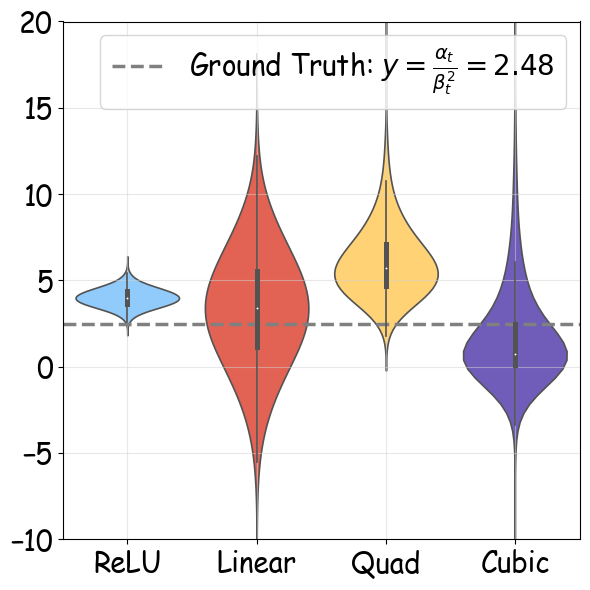

In [8]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm

# 设置 Comic Sans MS 字体
comic_sans_path = "/usr/share/fonts/truetype/msttcorefonts/comic.ttf"  # Linux 常见路径
if os.path.exists(comic_sans_path):
    fm.fontManager.addfont(comic_sans_path)
    plt.rcParams['font.family'] = 'Comic Sans MS'
else:
    print("Comic Sans MS font not found. Using default font.")

## 基本参数
mu = 1
m = 20
d = 100

# 时间参数 0.2, 0.4, 0.6, 0.8
time = 0.2
qs = [0, 1, 2, 3]

# 计算 alpha_t 和 beta_t
alpha_t = np.exp(-time)
beta_t = np.sqrt(1 - np.exp(-2 * time))

print(alpha_t, beta_t)

all_values = []

# 加载数据并计算
for q in qs:
    # 加载数据
    checkpoint_diff = torch.load(f'syn_diff_{time}_{q}.pth', map_location=torch.device('cpu'))

    state_dict = checkpoint_diff['model_state_dict']
    train_losses = checkpoint_diff['loss']
    feature_seris1 = checkpoint_diff['feature1']
    feature_seris2 = checkpoint_diff['feature2']

    model_static = CNN(m=m, d=d, q=q)
    model_static.load_state_dict(state_dict)

    n_test = 5000
    n_eps_test = 1

    test_x1, test_x2, feature1, feature2 = prepare_data(n_test)
    eps1 = torch.randn(n_test, d, n_eps_test)
    eps2 = torch.randn(n_test, d, n_eps_test)

    x1 = forward_diffusion(test_x1, time, eps1)
    x2 = forward_diffusion(test_x2, time, eps2)

    # 计算模型输出
    with torch.no_grad():
        psi = model_static.forward_without_residual(x1, x2, feature1, feature2).flatten()  # [n, n_eps]

    all_values.append(psi.numpy())

# 定义激活函数名称
acts = ['ReLU', 'Linear', 'Quad', 'Cubic']

# 定义颜色
# colors = ["#6f5db9", '#E26354', "#ffd275", "#91cbfb"]
colors = ["#91cbfb", '#E26354', "#ffd275", "#6f5db9"]

# 创建图表
plt.subplots(figsize=(6, 6))  # 增大图表尺寸
a = alpha_t / (beta_t**2)
plt.axhline(y=a, linestyle='--', label=rf'Ground Truth: $y = \frac{{\alpha_t}}{{\beta_t^2}} = {a:.2f}$', color='gray', linewidth=2.5)

# 创建小提琴图，调整 scale 和 bw 参数，并将中间的箱子设置为白色
sns.violinplot(
    data=all_values, 
    linewidth=1.2, 
    inner='box', 
    saturation=1, 
    palette=colors, 
    scale='width', 
    bw=0.5,
    inner_kws={'box': {'facecolor': 'white'}}  # 将中间的箱子设置为白色
)



# 设置 x 轴和 y 轴标记的字体大小
plt.xticks(ticks=range(len(acts)), labels=acts, fontsize=20)
plt.yticks(fontsize=20)

# 添加图例
plt.legend(fontsize=20)
plt.ylim(-10, 20)

# 调整布局
plt.tight_layout()
plt.grid(True, color='lightgray', alpha=0.5)

# 保存图表
save_path = '/cpfs04/user/hanyujin/causal-dm/causal_synthetic/fig'
if not os.path.exists(save_path):
    os.makedirs(save_path)

plt.savefig(os.path.join(save_path, f'diff_{time}.pdf'), dpi=300)

# 显示图表
plt.show()
plt.close()